## HR Analytics

### Analyzing Employee Turnover & Retention 

Employee turnover has been rising steadily, leading to high recruitment costs, loss of skilled talent, and disruption to business operations. This analysis was carried out to identify the factors driving attrition and uncover insights that can help the company improve employee retention and reduce turnover.


#### Table of Content
- <u>Introduction</u>
- <u>Data Gathering & Assessment</u>
- <u>Data Cleaning</u>
- <u>Univariate Exploration</u>
- <u>Bivariate Exploration</u>
- <u>Conclusion</u>
- <u>Recommendation</u>



## Data Gathering & Assessment

In [1]:
# importing all the libraries needed for the analysis
import pandas as pd  
import numpy as np 
import seaborn as sns  
import matplotlib.pyplot as plt  
%matplotlib inline  


In [2]:
# load the dataset into a pandas DataFrame
hr_df = pd.read_excel("Dataset/HR_Employee_Data.xlsx")  # read the Excel file into memory
hr_df.head()  # display the first few rows to inspect the dataset


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year
0,EMP02438,0.38,0.53,2,157,3,0,1,0,sales,low,0
1,EMP28133,0.80,0.86,5,262,6,0,1,0,sales,medium,0
2,EMP07164,0.11,0.88,7,272,4,0,1,0,sales,medium,0
3,EMP30478,0.72,0.87,5,223,5,0,1,0,sales,low,0
4,EMP24003,0.37,0.52,2,159,3,0,1,0,sales,low,0


In [3]:
### generate random samples of the dataset
hr_df.sample(10)

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year
11504,EMP27484,0.70,0.68,3,150,3,0,0,0,support,low,0
13067,EMP08332,0.78,0.40,4,145,5,1,0,1,sales,medium,1
7904,EMP18646,0.90,0.76,2,150,2,0,0,0,technical,medium,0
14642,EMP17553,0.41,0.57,2,160,3,0,1,0,support,low,0
13199,EMP11347,0.32,0.86,4,266,4,0,0,0,RandD,low,0
1616,EMP28682,0.37,0.46,2,156,3,0,1,0,sales,low,0
3747,EMP40378,0.96,0.53,5,224,4,0,0,0,sales,low,0
9528,EMP26740,0.27,0.85,2,277,6,1,0,0,IT,low,0
2161,EMP01720,0.63,0.57,4,177,3,1,0,0,sales,low,0
11688,EMP16614,0.94,0.90,4,144,4,0,0,0,support,low,0


In [4]:
#let's check how many rows and columns in the dataset
hr_df.shape

(14999, 12)

There are 14,999 rows and 12 columns in the dataset

In [5]:
#check the dataset info
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   Commute_time           14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
 11  Training_Last_Year     14999 non-null  int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 1.4+ MB


There's no null value in the dataset and and the data types are good  

In [6]:
#we can also check for null values 
hr_df.isnull().sum()

Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
Commute_time             0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
Training_Last_Year       0
dtype: int64

In [7]:
#check for duplicates
hr_df.duplicated().sum()

0

There's 0 null and duplicate values present in the dataset

In [8]:
#check for summary statistic
hr_df.describe(include='all')     #include=all adds the categorical variables to the summary

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year
count,14999,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999,14999.000000
unique,14999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3,NaN
top,EMP02438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316,NaN
mean,NaN,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN,0.027202
std,NaN,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN,0.162676
min,NaN,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
25%,NaN,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
50%,NaN,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
75%,NaN,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000


In [9]:
#check the number of unique values
hr_df.nunique()

Emp_Id                   14999
satisfaction_level          92
last_evaluation             65
number_project               6
average_montly_hours       215
Commute_time                 8
Work_accident                2
left                         2
promotion_last_5years        2
Department                  10
salary                       3
Training_Last_Year           2
dtype: int64

In [10]:
#checking value counts for the columns to check for unbalanced data, data inconsistencies, misspelling 
#check value count for Department column
hr_df.Department.value_counts()

sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: Department, dtype: int64

In [11]:
#check value count for salary column
hr_df.salary.value_counts()

low       7316
medium    6446
high      1237
Name: salary, dtype: int64

In [12]:
#save a copy of our current dataframe to keep the original data safe from changes
df= hr_df.copy()

In [13]:
df

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year
0,EMP02438,0.38,0.53,2,157,3,0,1,0,sales,low,0
1,EMP28133,0.80,0.86,5,262,6,0,1,0,sales,medium,0
2,EMP07164,0.11,0.88,7,272,4,0,1,0,sales,medium,0
3,EMP30478,0.72,0.87,5,223,5,0,1,0,sales,low,0
4,EMP24003,0.37,0.52,2,159,3,0,1,0,sales,low,0
...,...,...,...,...,...,...,...,...,...,...,...,...
14994,EMP40221,0.40,0.57,2,151,3,0,1,0,support,low,0
14995,EMP24196,0.37,0.48,2,160,3,0,1,0,support,low,0
14996,EMP33544,0.37,0.53,2,143,3,0,1,0,support,low,0
14997,EMP40533,0.11,0.96,6,280,4,0,1,0,support,low,0


## Exploratory Data Analysis

### Univariate Exploration

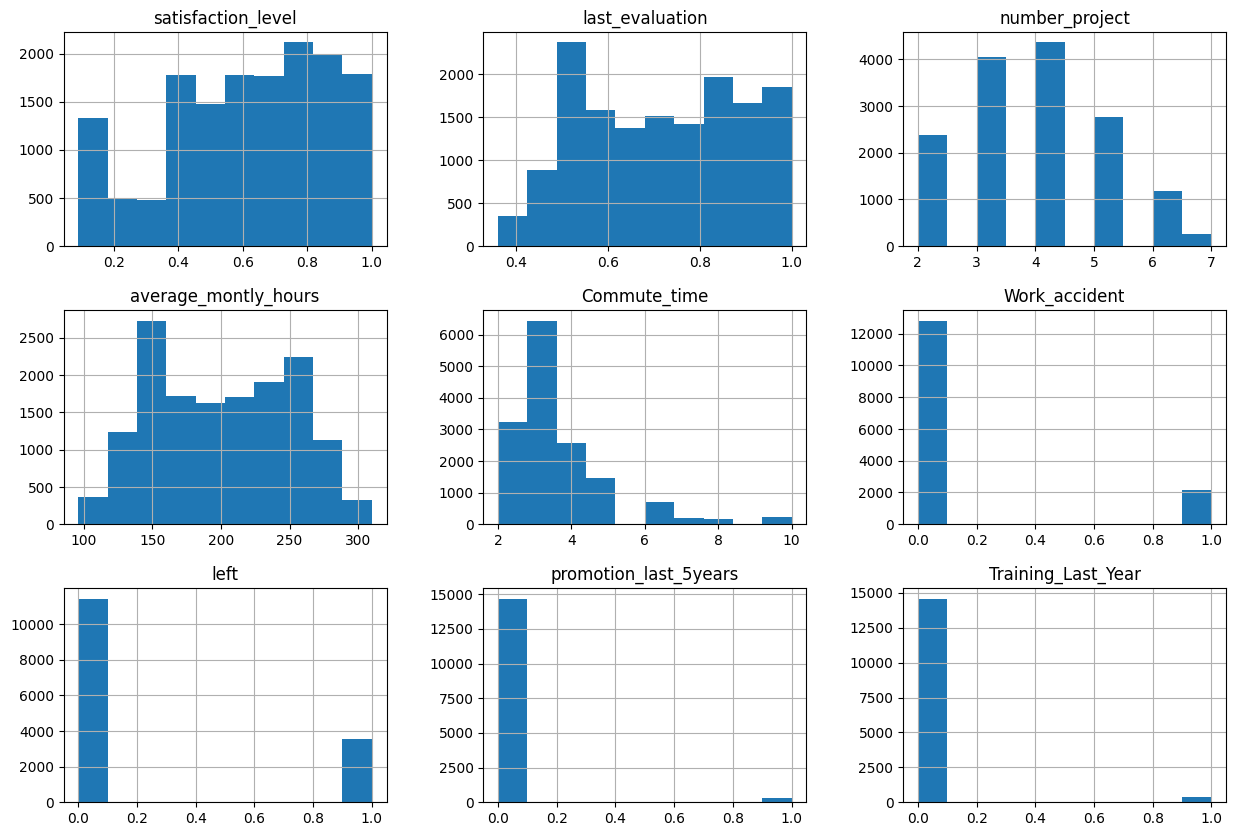

In [14]:
# visualize the distribution of all numerical variables in the DataFrame
df.hist(figsize=(15,10));  # create histograms for numeric columns and set the overall figure size


#### How does employee satisfaction vary across the dataset?

In [15]:
#employee satisfaction level statistic
df['satisfaction_level'].describe()

count    14999.000000
mean         0.612834
std          0.248631
min          0.090000
25%          0.440000
50%          0.640000
75%          0.820000
max          1.000000
Name: satisfaction_level, dtype: float64

**Satisfaction score statistical summary**
- The dataset represents a range of employee satisfaction levels, with most scores falling between 44% and 82%. The average satisfaction level is 61.3% indicating a moderate level of overall satisfaction.
- The scores have a moderate spread, with a standard deviationof approximately 0.249.
- The lowest satisfaction score is 9% while the highest is 100%.

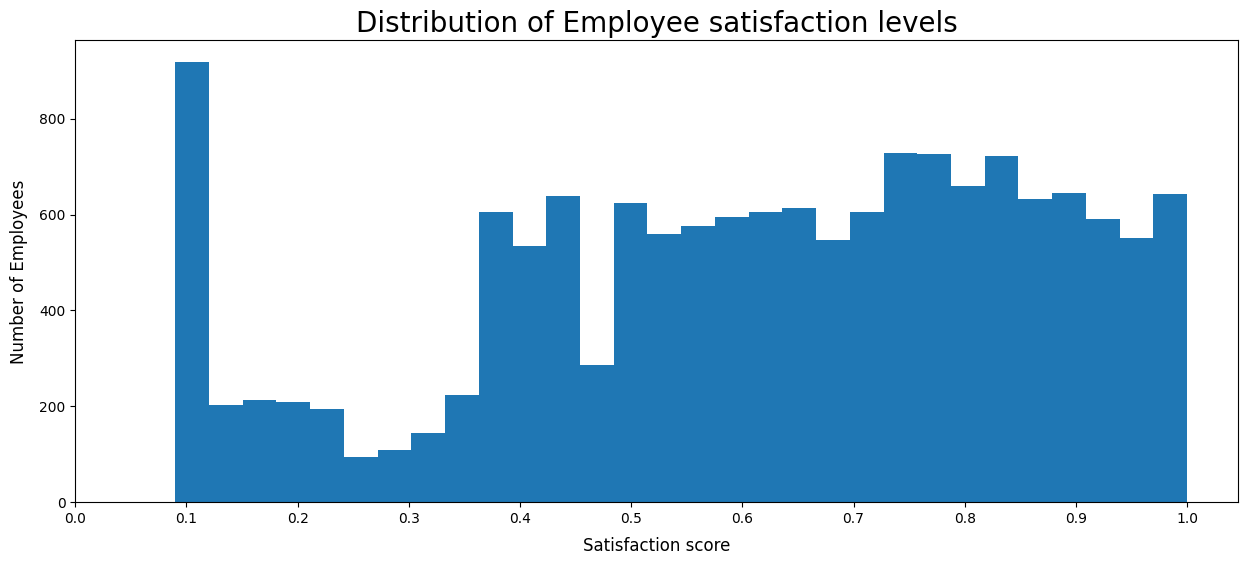

In [16]:
#histogram of satisfaction level
plt.figure(figsize=[15,6])   #sets the image size
bins = 30                    #number of bins (intervals) in the histogram

plt.hist(x=df.satisfaction_level, bins=bins)   #plots the histogram of the 'satisfaction_level' column

#set the x-axis ticks to be from 0.1 to 1 with a specified number of ticks (10 ticks)
tick_values = np.arange(0, 1.1, 0.1)
plt.xticks(tick_values)    #apply these tick values to the x-axis


#add chart title and labels with font size and padding
plt.title('Distribution of Employee satisfaction levels', fontsize=20)    #title of the plot
plt.xlabel('Satisfaction score', labelpad=8, fontsize=12)                 #label for x-axis
plt.ylabel('Number of Employees', labelpad=8, fontsize=12)                #label for y-axis

plt.show()  #display the plot

- The shape of the histogram looks multimodal with the data having more than 2 peaks. The histogram being multimodal suggests that there are multiple distinct groups or patterns within satisfaction levels among employees. This could be indicative of differing experiences or conditions within the organization that affect employee satisfaction.
- The histogram shows that over 800 employees have satisfaction scores of less than 15%. This large group of higly dissatisfied employees might indicate systemic issues or specific areas of the organization that are underperforming in terms of employee satisfaction.
- The peak around 40%, representing a group with satisfaction scores between 35-45%, suggests another distinct category of employees. This group is not as dissatisfied as the first one, but not fully satisfied either.

#### How does employee last performance vary across the dataset?

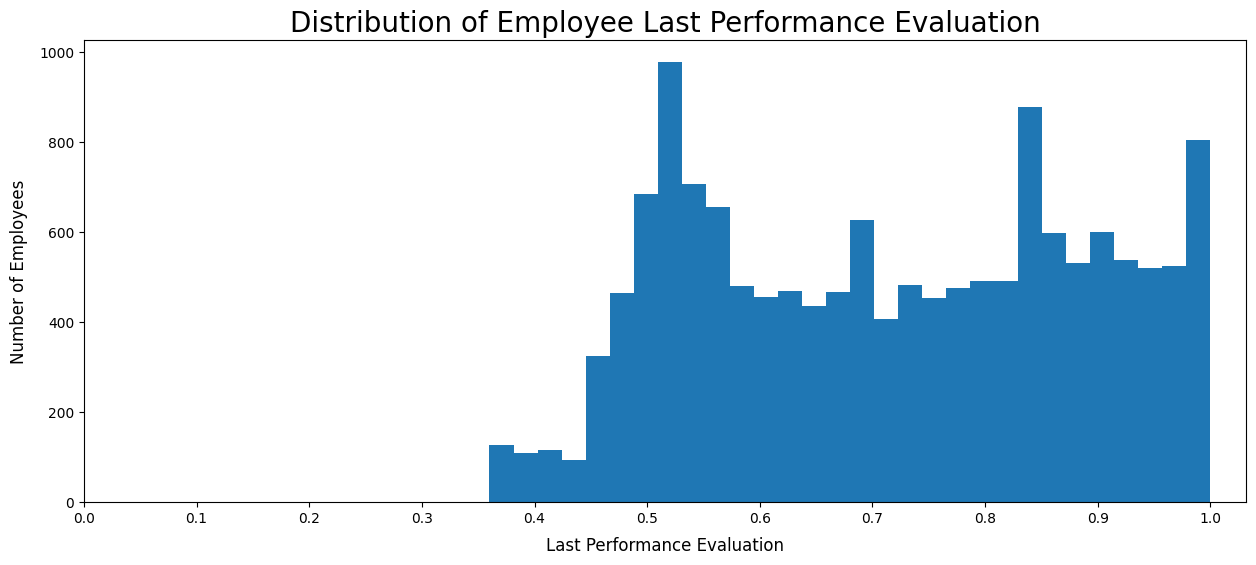

In [17]:
#histogram of last_evaluation
plt.figure(figsize=[15,6])   #sets the image size
bins = 30                    

plt.hist(x=df.last_evaluation, bins=bins)   

#set the x-axis ticks to be from 0.1 to 1 with a specified number of ticks (10 ticks)
tick_values = np.arange(0, 1.1, 0.1)
plt.xticks(tick_values)    


#add chart title and labels with font size and padding
plt.title('Distribution of Employee Last Performance Evaluation', fontsize=20)   
plt.xlabel('Last Performance Evaluation', labelpad=8, fontsize=12)                
plt.ylabel('Number of Employees', labelpad=8, fontsize=12)                

plt.show()  #display the plot

In [18]:
#employee last_evaluation statistic
df['last_evaluation'].describe()

count    14999.000000
mean         0.716102
std          0.171169
min          0.360000
25%          0.560000
50%          0.720000
75%          0.870000
max          1.000000
Name: last_evaluation, dtype: float64

- The average employee performance score is approximately 72%, indicating that most employees are evaluated above the midpoint on the 0–1 scale.
- The distribution is positively skewed with a minimum of 36% and a maximum of 100%, showing a few low-performing employees while a significant portion achieve high scores.
- 50% of employees have evaluations of 72%, suggesting a generally strong-performing workforce.
- Employees in the lowest quartile (<56%) may be at higher risk of turnover, and those in the highest quartile (>87%) are likely top performers whose retention is strategically important.
- The histogram shows distinct clusters around 0.55, 0.7, 0.85, and 1.0, implying the company may use discrete performance bands rather than a continuous scoring system.

### How does the average monthly hours worked by employees vary across the dataset?

In [19]:
#employee average_montly_hours statistic
df['average_montly_hours'].describe()

count    14999.000000
mean       201.050337
std         49.943099
min         96.000000
25%        156.000000
50%        200.000000
75%        245.000000
max        310.000000
Name: average_montly_hours, dtype: float64

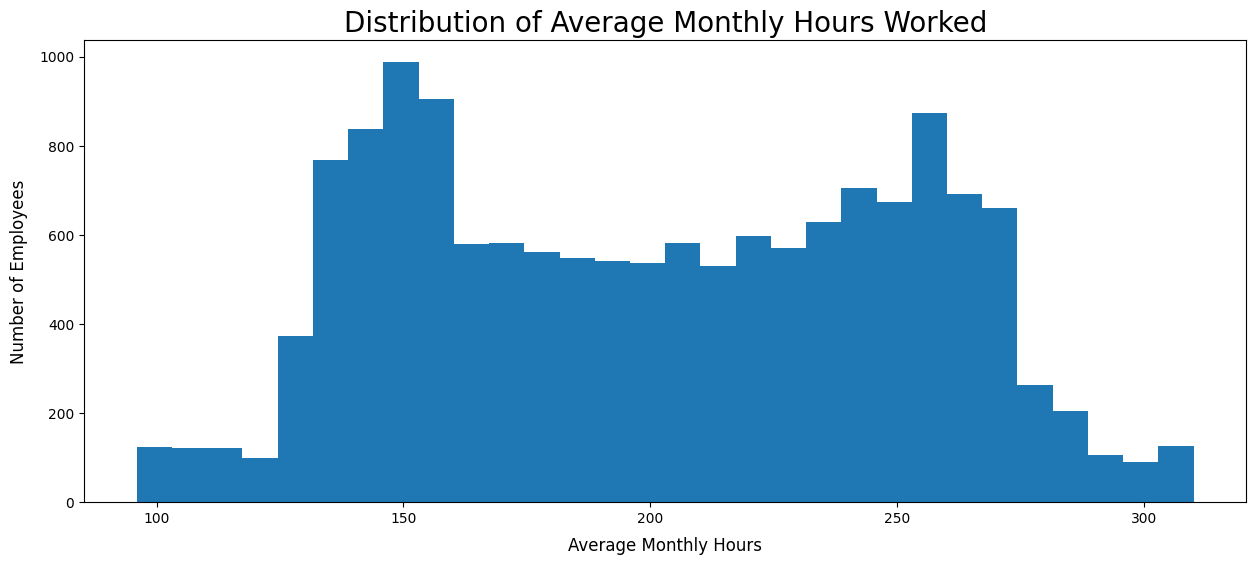

In [20]:
# histogram of average monthly hours worked
plt.figure(figsize=[15,6])   # set the figure size
bins = 30                    # define the number of histogram bins

plt.hist(x=df.average_montly_hours, bins=bins)  # plot the distribution of average monthly hours

# add chart title and axis labels
plt.title('Distribution of Average Monthly Hours Worked', fontsize=20)   # set the chart title
plt.xlabel('Average Monthly Hours', labelpad=8, fontsize=12)  # label the x-axis
plt.ylabel('Number of Employees', labelpad=8, fontsize=12)  # label the y-axis

plt.show()  # display the chart


- There are two peaks observed, One peak lies in the range of 150-200 hours, and the other peak is in the 250-300 hours range. This suggests that there are two distinct groups of employees based on their working hours.

### How does the commute time vary across the dataset?

In [21]:
#employee Commute time' statistic
df['Commute_time'].describe()

count    14999.000000
mean         3.498233
std          1.460136
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: Commute_time, dtype: float64

In [22]:
# set the default seaborn palette color for reuse across countplots and barplots
default_color = sns.color_palette()[0]  # pick the first color from seaborn's default color palette


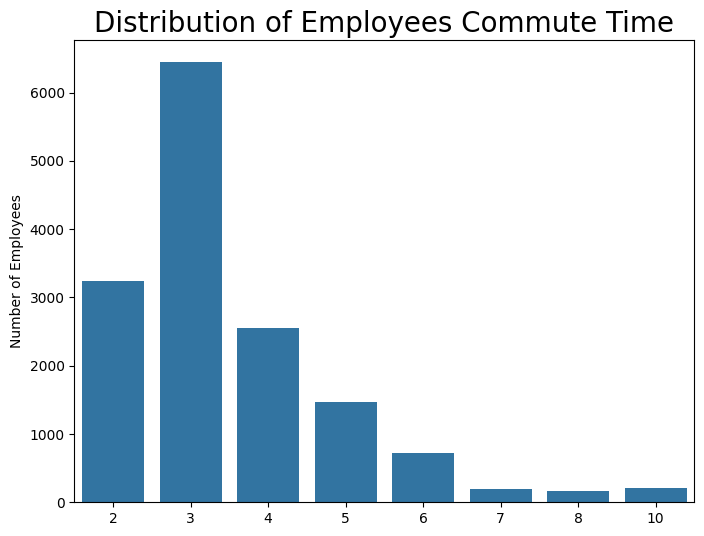

In [23]:
# plot the distribution of employee commute times
plt.figure(figsize=(8,6))  # create a new figure and set its size
sns.countplot(x=df.Commute_time, color=default_color)  # count employees in each commute-time category

plt.title('Distribution of Employees Commute Time', fontsize=20)  # add the chart title
plt.xlabel("")  # remove the x-axis label for a cleaner look
plt.ylabel("Number of Employees")  # label the y-axis

plt.show() 


The data is heavily skewed to the right. Quite a number of employees spend 6-10hours commuting to work which is a lot of travel.

### What is the distribution of employees across each department?

In [24]:
#Department value count
df['Department'].value_counts()

sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: Department, dtype: int64

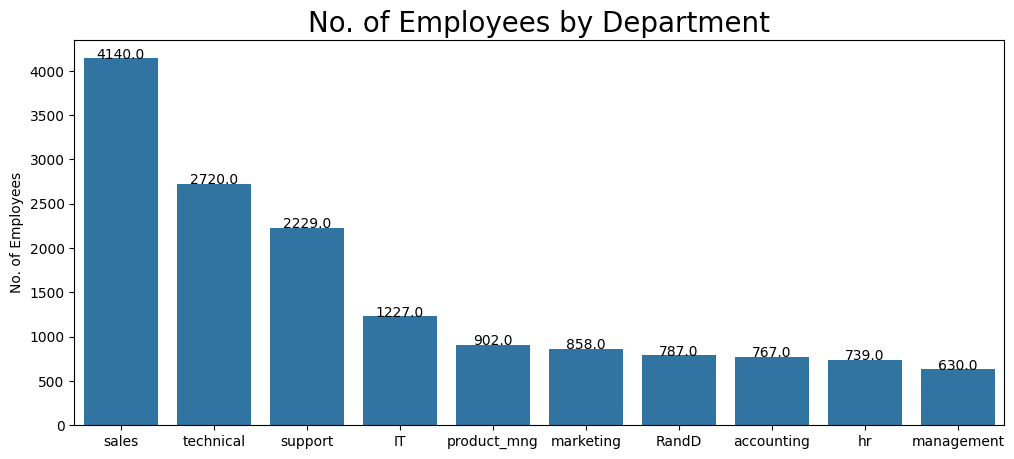

In [25]:
# plot the number of employees in each department
plt.figure(figsize=[12,5])  # create a wide figure for department labels
ax = sns.countplot(
    x=df.Department,
    color=default_color,
    order=df['Department'].value_counts().index)  # draw a countplot ordered by department size

# add data labels to each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='baseline')  # place the employee count above each bar
    
plt.title('No. of Employees by Department', fontsize=20)  # add the chart title
plt.xlabel("")  # remove the x-axis label
plt.ylabel("No. of Employees")  # label the y-axis

plt.show()  


The sales team have the highest number of employees, while the management team has the least employees

### What is the distribution of employees salary?

In [26]:
#Salary value count
df['salary'].value_counts()

low       7316
medium    6446
high      1237
Name: salary, dtype: int64

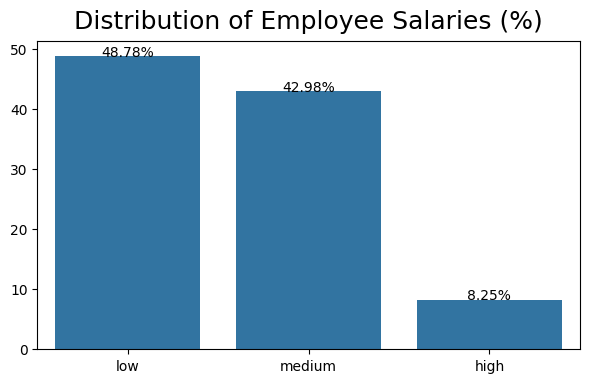

In [27]:
# plot the percentage distribution of employee salary categories
plt.figure(figsize=[7,4])  # create a compact figure for the salary chart

# calculate the percentage share of each salary category
salary_percentages = (df['salary'].value_counts() / len(df)) * 100  # convert salary counts to percentages

ax = sns.barplot(
    x=salary_percentages.index,
    y=salary_percentages,
    color=default_color,
    order=salary_percentages.index)  # plot salary-category percentages

# add percentage labels above each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')  # display the salary percentage on each bar
    
plt.title('Distribution of Employee Salaries (%)', fontsize=18, y=1.015)  # add the chart title
plt.xlabel("")  # remove the x-axis label
plt.ylabel("")  # remove the y-axis label

plt.show()  # display the chart


Only 8.25% of employees earn high salaries. 48.7% earn low salaries and 42.9% earn medium salaries

### What is the distribution of employees that got promoted in the last 5 years?

In [28]:
#Promotion for the last 5 years value count
df['promotion_last_5years'].value_counts()

0    14680
1      319
Name: promotion_last_5years, dtype: int64

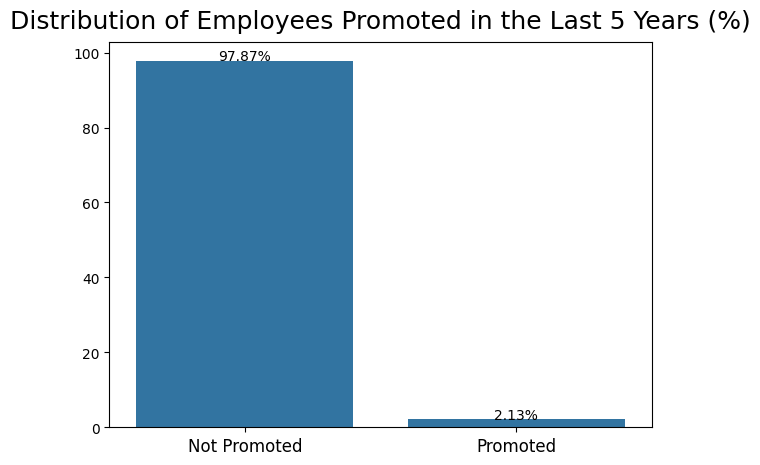

In [29]:
# plot the percentage of employees promoted in the last 5 years
plt.figure(figsize=[7,5])  # create a figure for the promotion chart

# calculate the percentage share of promoted vs not promoted employees
promotion_percentages = (df['promotion_last_5years'].value_counts() / len(df)) * 100  # convert counts to percentages

# create a barplot with percentage values
ax = sns.barplot(
    x=promotion_percentages.index,
    y=promotion_percentages,
    color=default_color,
    order=promotion_percentages.index)  # draw the promotion percentage chart

# set x-axis labels and chart title
plt.xticks(ticks=[0,1], labels=['Not Promoted', 'Promoted'], fontsize=12)  # replace binary values with readable labels
plt.title('Distribution of Employees Promoted in the Last 5 Years (%)', fontsize=18, y=1.015)  # add title
plt.xlabel("")  # remove the x-axis label
plt.ylabel("")  # remove the y-axis label

# add percentage labels above each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()), ha='center',va='baseline'  )  # display the promotion percentage on each bar

plt.show()  # display the chart


Only 2% of employees were promoted in the last 5 years which is quite low and this indicates that there is very little room for career growth within the company.

### What percentage of employees were Trained in the last year?

In [30]:
#Training last year value count
df['Training_Last_Year'].value_counts()

0    14591
1      408
Name: Training_Last_Year, dtype: int64

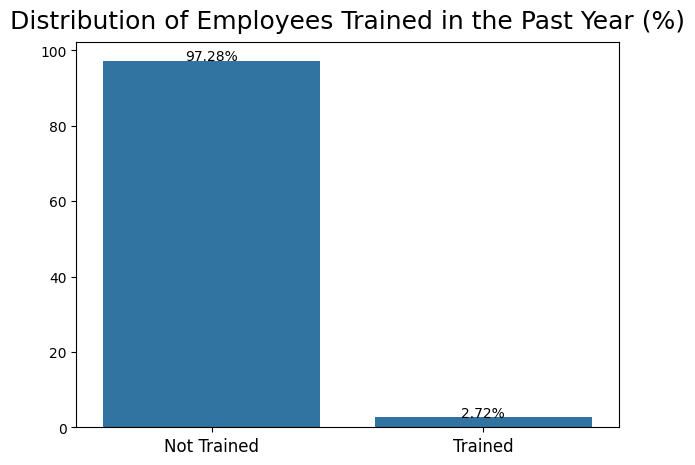

In [31]:
# plot the percentage of employees who received training in the past year
plt.figure(figsize=[7,5])  # create a figure for the training chart

# calculate the percentage share of trained vs not trained employees
trained_percentages = (df['Training_Last_Year'].value_counts() / len(df)) * 100  # convert counts to percentages

# create a barplot with percentage values
ax = sns.barplot(
    x=trained_percentages.index,
    y=trained_percentages,
    color=default_color,
    order=trained_percentages.index)  # draw the training percentage chart

# set x-axis labels and chart title
plt.xticks(ticks=[0,1], labels=['Not Trained', 'Trained'], fontsize=12)  # replace binary values with readable labels
plt.title('Distribution of Employees Trained in the Past Year (%)', fontsize=18, y=1.015)  # add title
plt.xlabel("")  # remove the x-axis label
plt.ylabel("")  # remove the y-axis label

# add percentage labels above each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),ha='center',va='baseline')  # display the training percentage on each bar

plt.show()  # display the chart


Only 2.7% of employees were trained in the past year.

### What percentage of employees were involved in a work accident?

In [32]:
#Work accident value count
df['Work_accident'].value_counts()

0    12830
1     2169
Name: Work_accident, dtype: int64

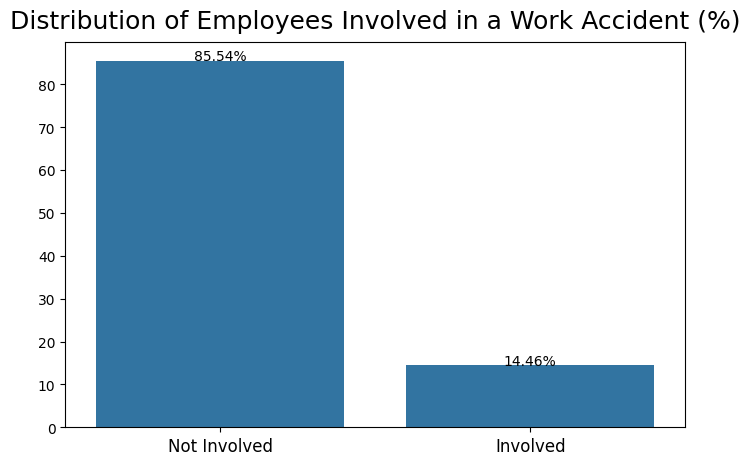

In [33]:
# plot the percentage of employees involved in work accidents
plt.figure(figsize=[8,5])  # create a figure for the accident chart

# calculate the percentage share of accident involvement
accident_percentages = (df['Work_accident'].value_counts() / len(df)) * 100  # convert counts to percentages

# create a barplot with percentage values
ax = sns.barplot(
    x=accident_percentages.index,
    y=accident_percentages,
    color=default_color,
    order=accident_percentages.index)  # draw the accident percentage chart

# set x-axis labels and chart title
plt.xticks(ticks=[0,1], labels=['Not Involved', 'Involved'], fontsize=12)  # replace binary values with readable labels
plt.title('Distribution of Employees Involved in a Work Accident (%)', fontsize=18, y=1.015)  # add title
plt.xlabel("")  # remove the x-axis label
plt.ylabel("")  # remove the y-axis label

# add percentage labels above each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')  # display the accident percentage on each bar

plt.show()  # display the chart


Approximately 14.46% of the workforce had a work accident during their tenure

### What is the percentage of employee turnover?


In [34]:
#employee turnover value count
df['left'].value_counts()


0    11428
1     3571
Name: left, dtype: int64

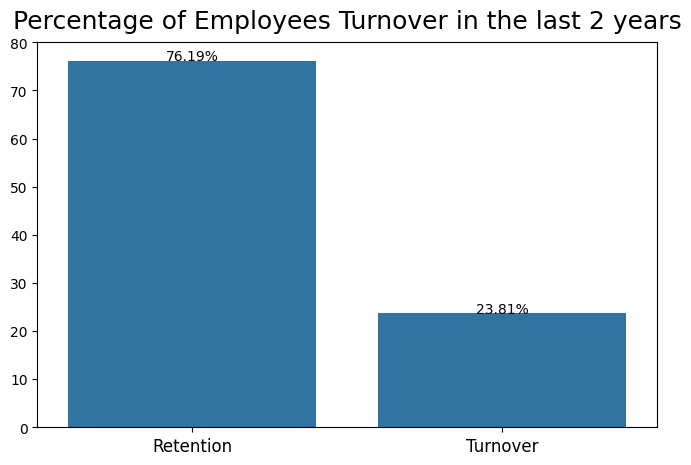

In [35]:
# plot the percentage of employees who stayed versus those who left
plt.figure(figsize=[8,5])  # create a figure for the turnover chart

# calculate the percentage share of retained vs departed employees
left_percentages = (df['left'].value_counts() / len(df)) * 100  # convert employee status counts to percentages

# create a barplot with percentage values
ax = sns.barplot(
    x=left_percentages.index,
    y=left_percentages,
    color=default_color,
    order=left_percentages.index)  # draw the employee turnover percentage chart

# set x-axis labels and chart title
plt.xticks(ticks=[0,1], labels=['Retention', 'Turnover'], fontsize=12)  # replace binary values with readable labels
plt.title('Percentage of Employees Turnover in the last 2 years', fontsize=18, y=1.015)  # add title
plt.xlabel("")  # remove the x-axis label
plt.ylabel("")  # remove the y-axis label

# add percentage labels above each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),ha='center',va='baseline')  # display the turnover percentage on each bar

plt.show()  # display the chart


Approximately 23.8% of the workforce left the company

## BIVARIATE EXPLORATION

I will use bivariate analysis to identify the factors that most influence employee retention. Our target variable is the `left`
variable, and our independent variables include `satisfaction_level`, `last_evaluation`, `number_project`, `average_montly_hours`, `promotion_last_5years`, etc.

I will also examine how each variable relates to the target variable, which is whether or not an employee left the company.The following questions have will be answered to achieve this goal:

- Which department has the highest number of employees leaving the company?
- Do employees with higher salaries tend to stay longer? Is there a relationship between salary and employee retention?
- Is there a correlation between employee satisfaction levels and their retention within the organization?
- How do the performance evaluation scores differ between employees who leave and those who stay?
- Do employees who work on more projects have higher turnover rates?
- Do employees who work longer hours have higher turnover rates?
- How does commute time affect employee retention?
- Do work accidents lead to employees leaving the company?
- Are employees who are promoted more or less likely to stay with the company?
- How many employees who were trained in the past year decided to remain with the company?

### 1. Which department has the highest employee turnover and retention rate?

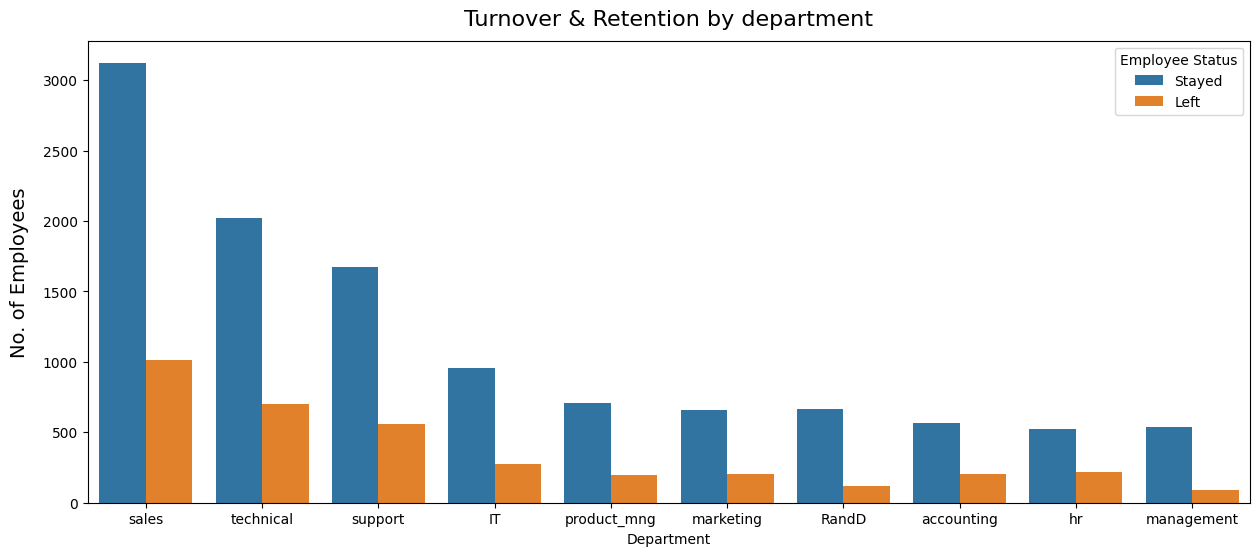

In [36]:
# plot turnover and retention by department
plt.figure(figsize=[15,6])  # create a wide figure for department-level comparison

sns.countplot(
    data=df,x=df["Department"],hue='left',
    order=df["Department"].value_counts().index)  # compare stayed vs left employees across departments

plt.title('Turnover & Retention by department', fontsize=16, y=1.015)  # add the chart title
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis
plt.legend(title='Employee Status', labels=['Stayed', 'Left'])  # customize the legend labels

plt.show(); 


Sales, Technical and Support team have the highest number of employees leaving the company. Management has the last number of employees leaving the company.

### 2. Do employees with higher salaries tend to stay longer? Is there a relationship between salary and employee retention?

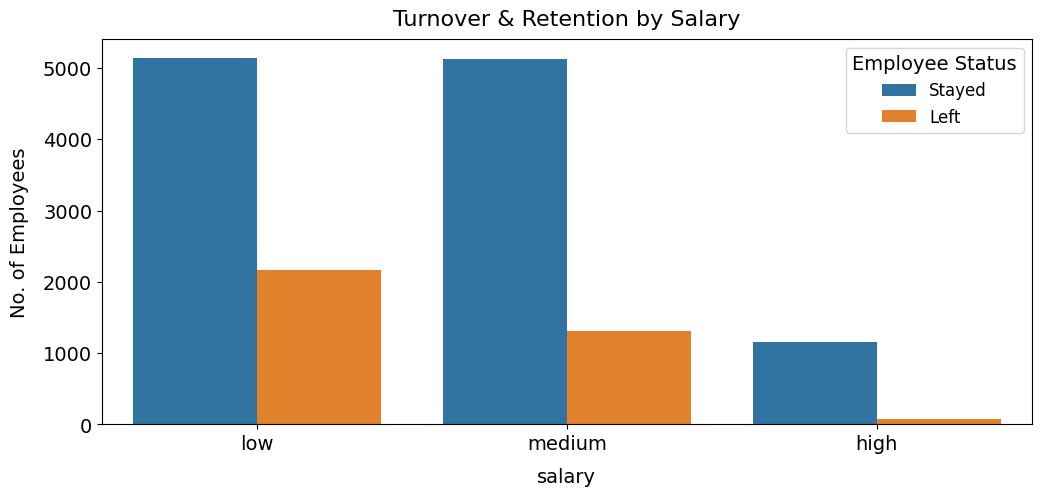

In [37]:
# plot turnover and retention across salary categories
plt.figure(figsize=[12,5])  # create a figure for the salary comparison chart
ax = sns.countplot(
    data=df,
    x='salary',
    hue='left',
    order=df['salary'].value_counts().index)  # compare stayed vs left employees by salary level

plt.title('Turnover & Retention by Salary', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('salary', labelpad=10, fontsize=14)  # label the x-axis
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis

# adjust the tick label sizes for readability
ax.tick_params(axis='x', labelsize=14)  # set the x-axis tick label size
ax.tick_params(axis='y', labelsize=14)  # set the y-axis tick label size

plt.legend(title='Employee Status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend
plt.show();  


Employees with higher salaries tends to stay longer with the organization. Employees with lower salaries are more likely to leave the organization.

### 3. Is there a correlation between employee satisfaction levels and their retention within the organization?


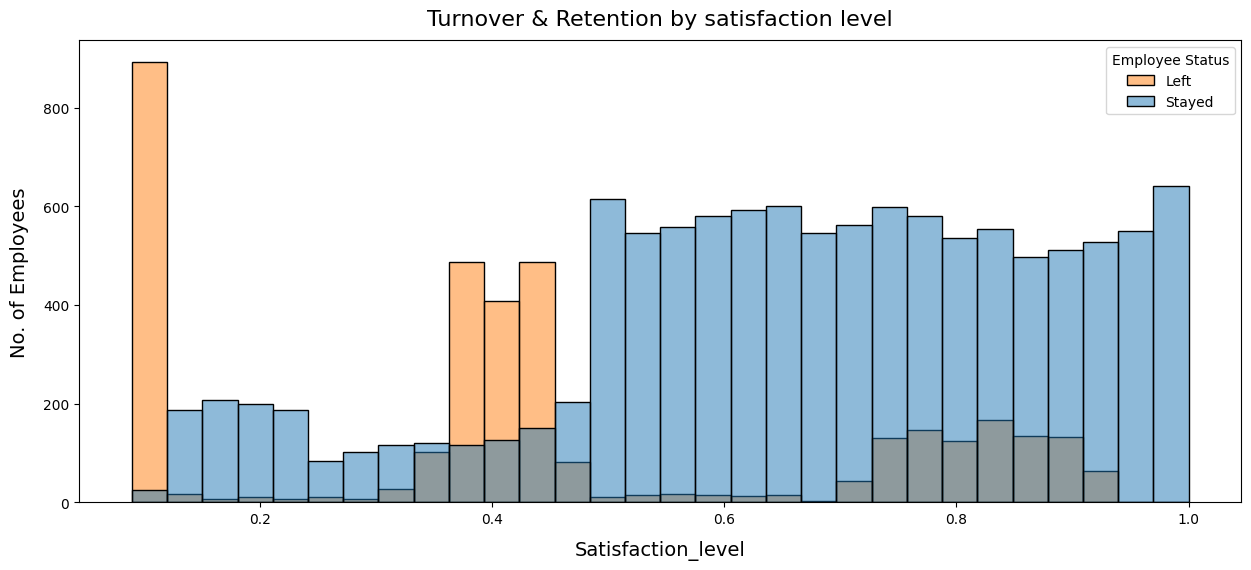

In [38]:
# plot the distribution of satisfaction level by employee status
plt.figure(figsize=[15,6])  # create a wide figure for the histogram
sns.histplot(data=df, x='satisfaction_level', hue='left')  # compare satisfaction distributions for stayed vs left employees
plt.title('Turnover & Retention by satisfaction level', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('Satisfaction_level', labelpad=10, fontsize=14)  # label the x-axis
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis
plt.legend(title='Employee Status', labels=['Left', 'Stayed'])  # customize the legend labels

plt.show();  


- There is a noticeable cluster of employees who left the company at the lower end of the satisfaction scale, indicating that lower satisfaction levels are associated with higher tumover.
- Employees who have stayed with the company tend to have a wider distribution of satisfaction levels, but with a concentration towards the higher end of the scale.
- There is also a smaller peak of employees who left at high satisfaction levels, which might suggest that some other factors beyond satisfaction are influencing the decision to leave.

I will segment the satisfaction scores into groups to properly visualize this trend.

* Very Dissatisfied: 1% - 25%
* Dissatisfied: 25% - 50%
* Neutral: 51% - 60%
* Satisfied: 61% - 80%
* Very Satisfied: 81% - 100%

In [39]:
# Define the bins for satisfaction Levels
bins= [0, 0.25, 0.50, 0.60, 0.80, 1.0]
labels = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']

# Create a new column 'Satisfaction Level' by cutting the 'satisfaction level" into bins
df['Satisfaction Level'] = pd.cut(df['satisfaction_level'], bins=bins, labels=labels, include_lowest=True)

In [40]:
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year,Satisfaction Level
0,EMP02438,0.38,0.53,2,157,3,0,1,0,sales,low,0,Dissatisfied
1,EMP28133,0.80,0.86,5,262,6,0,1,0,sales,medium,0,Satisfied
2,EMP07164,0.11,0.88,7,272,4,0,1,0,sales,medium,0,Very Dissatisfied
3,EMP30478,0.72,0.87,5,223,5,0,1,0,sales,low,0,Satisfied
4,EMP24003,0.37,0.52,2,159,3,0,1,0,sales,low,0,Dissatisfied


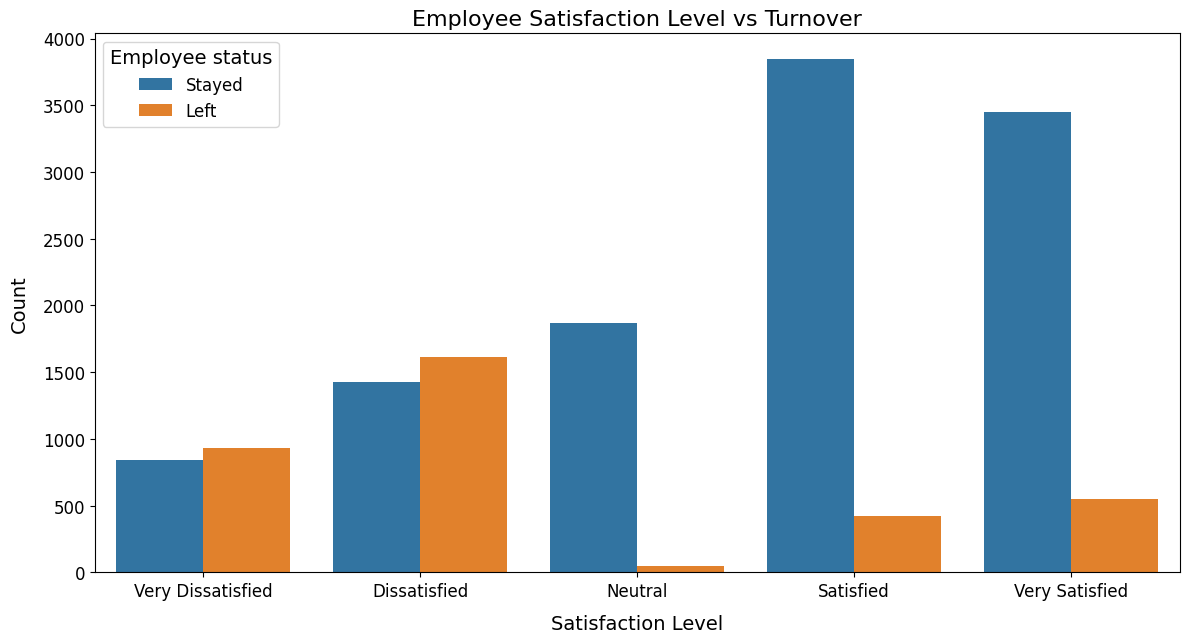

In [41]:
# visualize satisfaction bands against employee status
plt.figure(figsize=[14,7])  # create a large figure for the countplot

ax = sns.countplot(data=df, x='Satisfaction Level', hue='left')  # compare stayed vs left employees across satisfaction categories

plt.title('Employee Satisfaction Level vs Turnover', fontsize=16)  # add the chart title
plt.xlabel('Satisfaction Level', labelpad=10, fontsize=14)  # label the x-axis
plt.ylabel('Count', labelpad=10, fontsize=14)  # label the y-axis

ax.tick_params(axis='x', labelsize=12)  # format x-axis tick label size
ax.tick_params(axis='y', labelsize=12)  # format y-axis tick label size
plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend

plt.show(); 


- There is a substantial number of employees who left the company in the Very Dissatisfied and Dissatisfied categories, suggesting a strong link between low satisfaction levels and high turnover.
- The Neutral category shows a smaller, yet significant, number of employees leaving, which could imply that even a lack of strong positive or negative feelings can be associated with turnover.
- The Satisfied and Very Satisfied categories have higher counts of employees who stayed, which supports the idea that higher satisfaction correlates with better retention. However, there are still employees who left the company despite being in the Satisfied and Very Satisfied categories, indicating that satisfaction is not the sole factor in an employee's decision to stay or leave

### 3a. Which department has the employees with low satisfaction score?

In [42]:
df[df['satisfaction_level']<=0.5]

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year,Satisfaction Level
0,EMP02438,0.38,0.53,2,157,3,0,1,0,sales,low,0,Dissatisfied
2,EMP07164,0.11,0.88,7,272,4,0,1,0,sales,medium,0,Very Dissatisfied
4,EMP24003,0.37,0.52,2,159,3,0,1,0,sales,low,0,Dissatisfied
5,EMP08609,0.41,0.50,2,153,3,0,1,0,sales,low,0,Dissatisfied
6,EMP14345,0.10,0.77,6,247,4,0,1,0,sales,low,0,Very Dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,EMP40221,0.40,0.57,2,151,3,0,1,0,support,low,0,Dissatisfied
14995,EMP24196,0.37,0.48,2,160,3,0,1,0,support,low,0,Dissatisfied
14996,EMP33544,0.37,0.53,2,143,3,0,1,0,support,low,0,Dissatisfied
14997,EMP40533,0.11,0.96,6,280,4,0,1,0,support,low,0,Very Dissatisfied


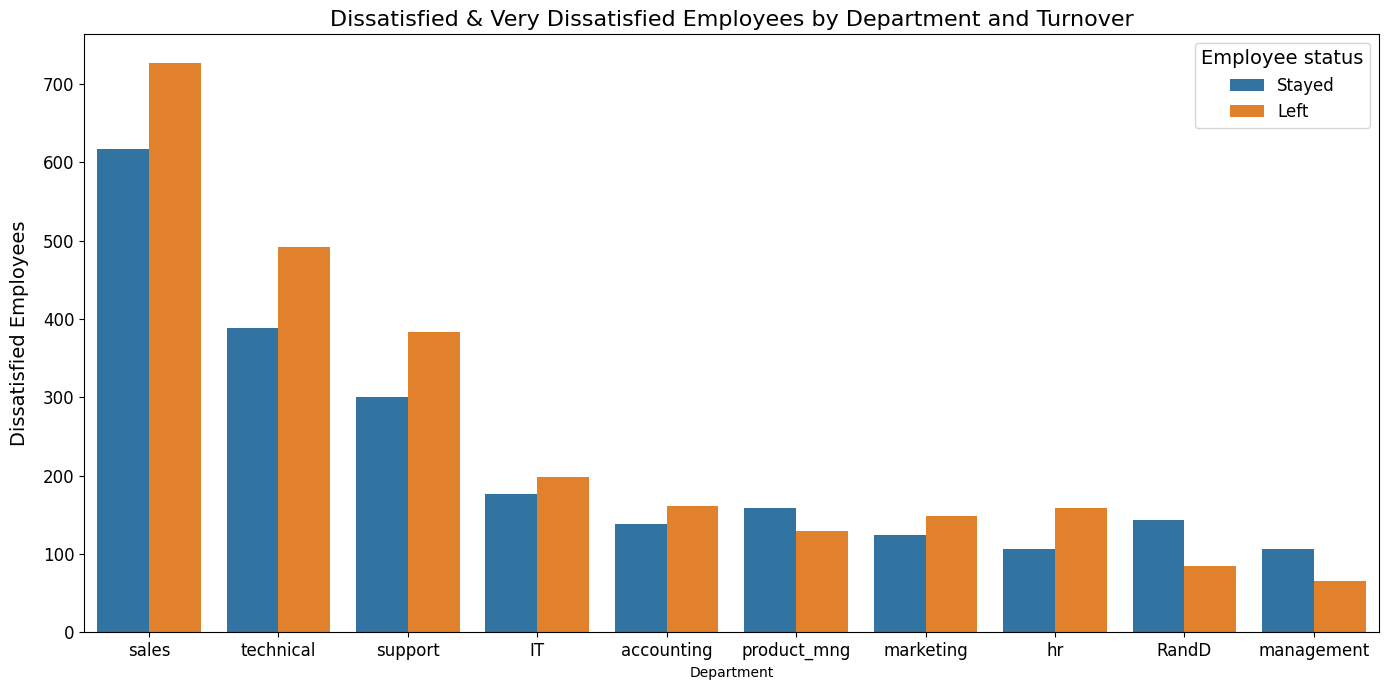

In [43]:
# select employees with low satisfaction scores
dissatisfied_employees = df[df['satisfaction_level'] <= 0.5]  # filter employees who are dissatisfied or very dissatisfied

# plot dissatisfied employees by department and employee status
plt.figure(figsize=[14,7])  # create a large figure for the departmental comparison
ax = sns.countplot(
    data=dissatisfied_employees,
    x='Department',
    hue='left',
    order=dissatisfied_employees['Department'].value_counts().index)  # compare stayed vs left dissatisfied employees by department

plt.title('Dissatisfied & Very Dissatisfied Employees by Department and Turnover', fontsize=16)  # add the chart title
plt.ylabel('Dissatisfied Employees', labelpad=10, fontsize=14)  # label the y-axis

ax.tick_params(axis='x', labelsize=12)  # format x-axis tick labels
ax.tick_params(axis='y', labelsize=12)  # format y-axis tick labels
plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend
plt.tight_layout()  # adjust spacing to prevent label overlap

plt.show();  


The sales, techincal and support departments are the top 3 departments with the most number of dissatisfied employees and more than half of these employees have left the company.


### 4. How do the performance evaluation scores differ between employees who leave and those who stay?

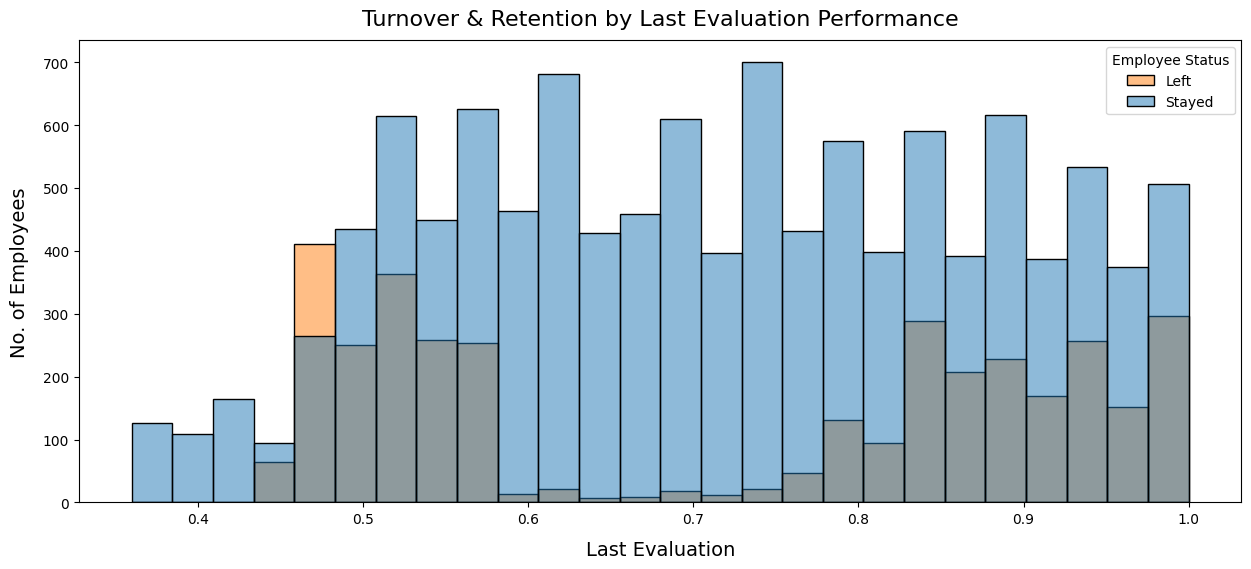

In [44]:
# plot last evaluation scores by employee status
plt.figure(figsize=[15,6])  # create a wide figure for the histogram
sns.histplot(data=df, x='last_evaluation', hue='left')  # compare evaluation score distributions for stayed vs left employees
plt.title('Turnover & Retention by Last Evaluation Performance', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('Last Evaluation', labelpad=10, fontsize=14)  # label the x-axis
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis
plt.legend(title='Employee Status', labels=['Left', 'Stayed'])  # customize the legend labels

plt.show();  


From the histogram, I observed;
- A bimodal distribution for employees who left, with peaks around scores of 0.45 and 0.9. This suggests that both low-performing and high-performing employees are leaving the company.
- There is a significant number of employees who left with high evaluation scores, which could indicate that even high performers are at rish of turnover.


### 5. Do employees who work on more projects have higher turnover rates?

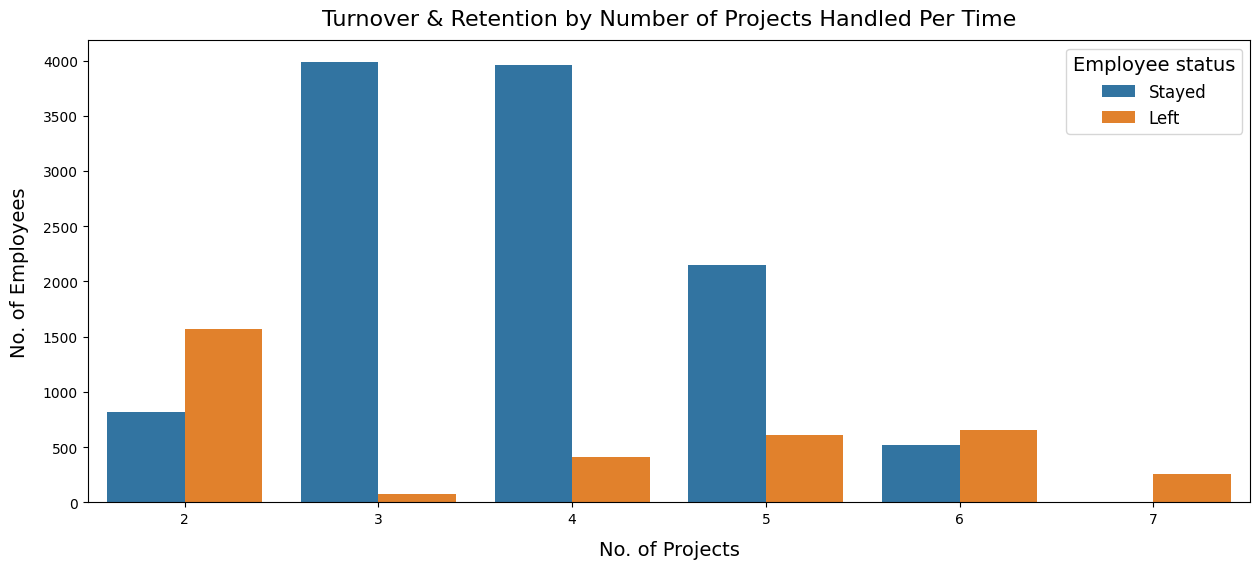

In [45]:
# plot turnover and retention by number of projects
plt.figure(figsize=[15,6])  # create a wide figure for the project count comparison

sns.countplot(data=df, x='number_project', hue='left')  # compare stayed vs left employees by number of projects handled

plt.title('Turnover & Retention by Number of Projects Handled Per Time', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('No. of Projects', labelpad=10, fontsize=14)  # label the x-axis
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis

plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend

plt.show();  


- Employees who have handled 3 projects have the highest retention rate, and a relatively low turnover rate compared to those with a higher or lower number of projects.
- There's a high turnover rate among employees who have handled six or seven projects, which could imply that a higher workload or overcommitment might be linked to burnout and subsequent turnover.
- Employees with at most 2 project also show a higher tendency to leave, which could suggest that underutilization or lack of engagement might be a factor in their decision to leave.
- Those who have handled three to five projects show a mixed turnover and retention pattern, suggesting that there might be a 'sweet spot in terms of project load that balances employee engagement without leading to burnout.

### 6. Do employees who work longer hours have higher turnover rates?

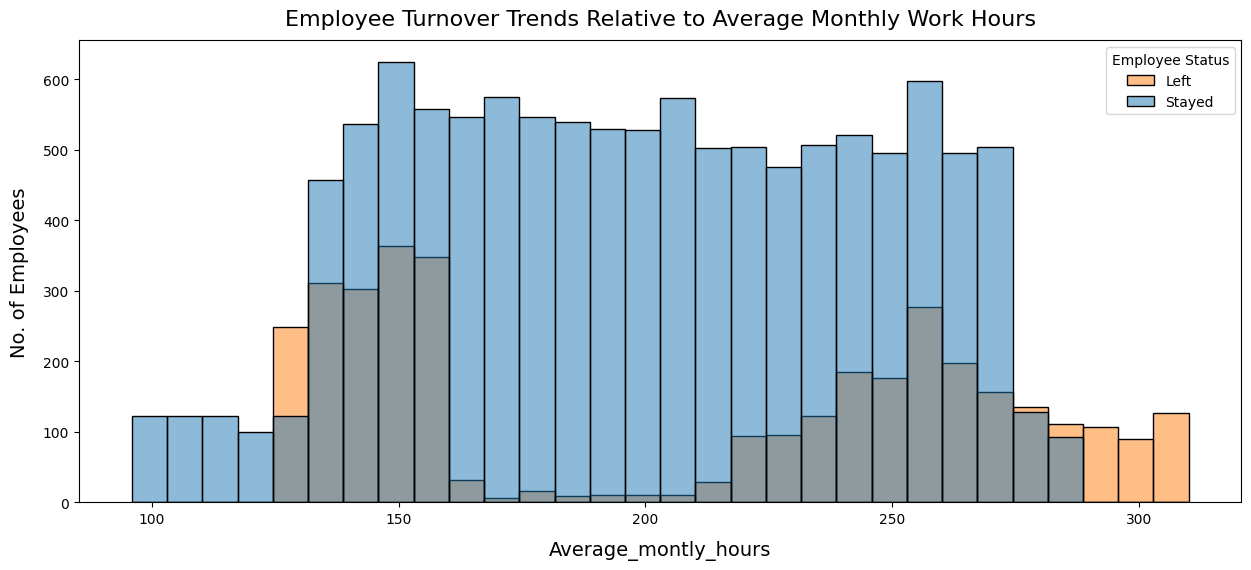

In [46]:
# plot average monthly hours by employee status
plt.figure(figsize=[15,6])  # create a wide figure for the histogram
sns.histplot(data=df, x='average_montly_hours', hue='left')  # compare monthly-hours distributions for stayed vs left employees
plt.title('Employee Turnover Trends Relative to Average Monthly Work Hours', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('Average_montly_hours', labelpad=10, fontsize=14)  # label the x-axis
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis
plt.legend(title='Employee Status', labels=['Left', 'Stayed'])  # customize the legend labels

plt.show(); 


- There are two notable peaks for employees who left the company: one for those working fewer hours (less than 160hrs) possibly indicating underemployment or dissatisfaction with part-time work, and one for those working longer hours (>200 hrs) which indicates that employees who consistently work overtime or long hours are at a higher risk of leaving, possibly due to burnout, stress, or insufficient work-life balance.
- Employees who stayed with the company tend to have a more normally distributed pattern of average hours, peaking around the median work hours. This might suggest that employees with a balanced workload are more likely to stay.

### 7. How does commute time affect employee retention?

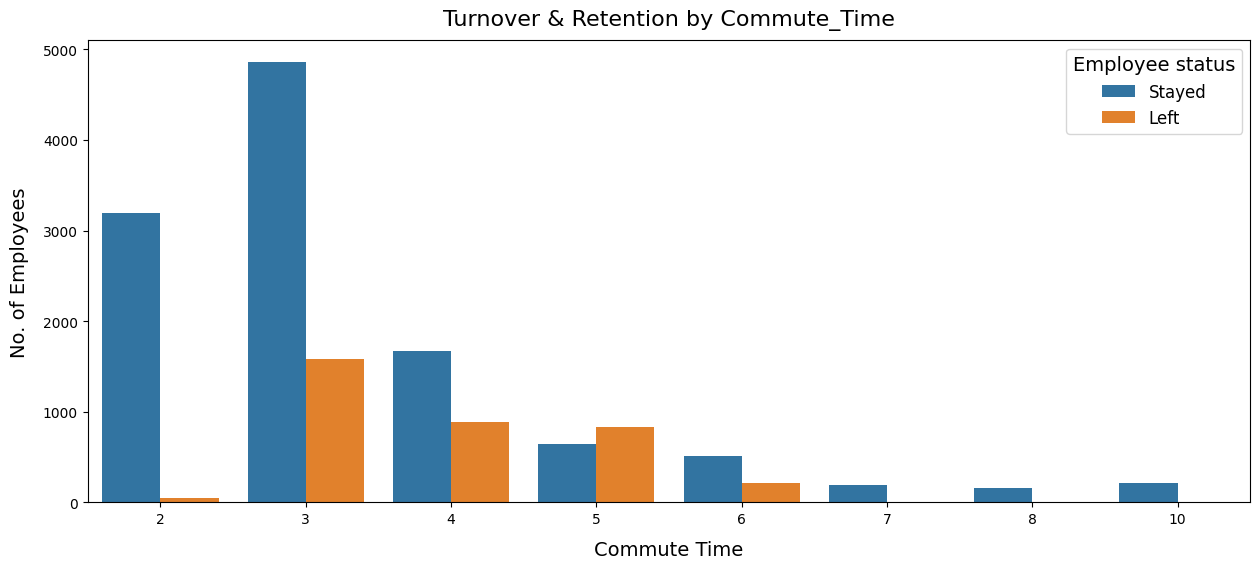

In [47]:
# plot turnover and retention across commute-time groups
plt.figure(figsize=[15,6])  # create a wide figure for the commute comparison

sns.countplot(data=df, x='Commute_time', hue='left')  # compare stayed vs left employees by commute time category

plt.title('Turnover & Retention by Commute_Time', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('Commute Time', labelpad=10, fontsize=14)  # label the x-axis
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis

plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend

plt.show();  


From the visualization, I can observe the following:
- Employees with shorter commute times (2hrs) tend to stay with the company. As the commute time increases, there appears to be an increase in the number of employees who left the company. This could indicate that as the commute becomes more burdensome, it may contribute to an employee's decision to leave.
- Surprisingly, employees that spend 7-10 hrs in transit have stayed with the company.

#### Lets investigate the department and salary of the employees with longer hours commute time who stayed with the company


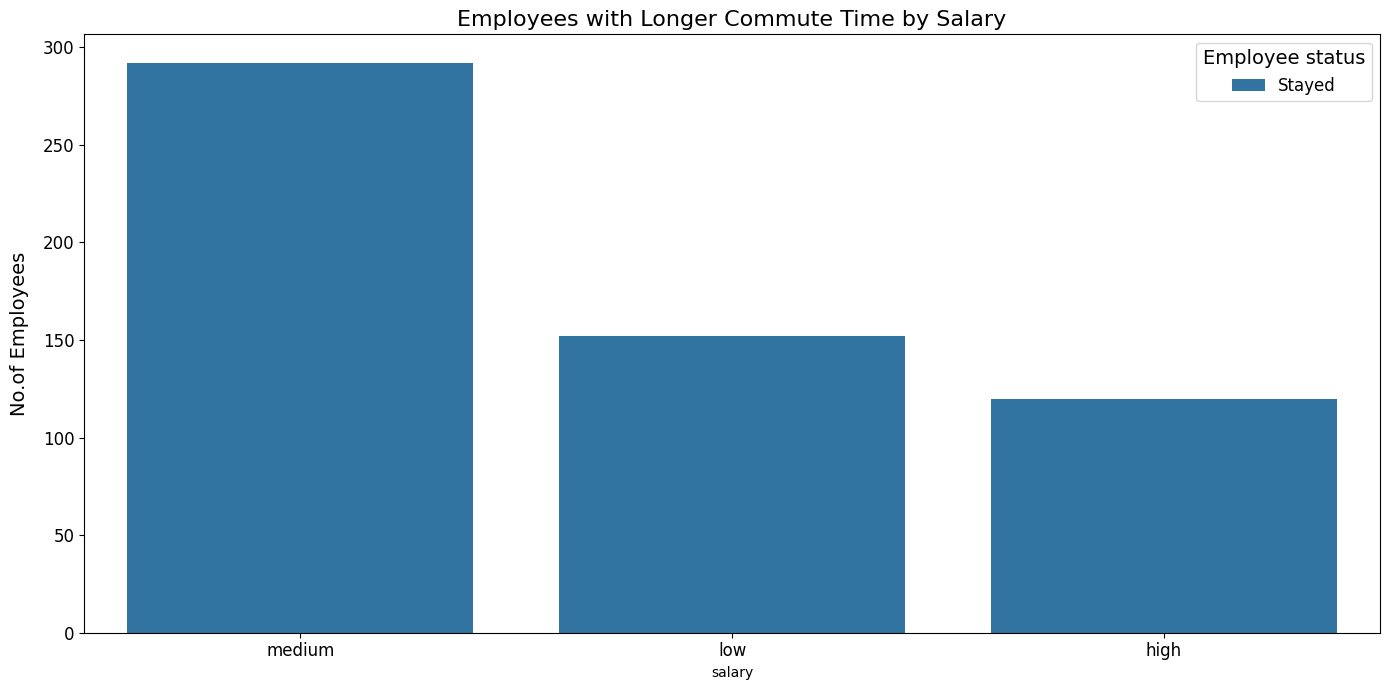

In [48]:
# select employees with longer commute times
longer_commute = df[df['Commute_time'] >= 7]  # filter employees whose commute time is 7 or more

# visualize employees with longer commute times by salary and employee status
plt.figure(figsize=[14,7])  # create a large figure for the salary comparison
ax = sns.countplot(
    data=longer_commute,
    x='salary',
    hue='left',
    order=longer_commute['salary'].value_counts().index)  # compare stayed vs left employees with long commutes across salary bands

plt.title('Employees with Longer Commute Time by Salary', fontsize=16)  # add the chart title
plt.ylabel('No.of Employees', labelpad=10, fontsize=14)  # label the y-axis

ax.tick_params(axis='x', labelsize=12)  # format x-axis tick labels
ax.tick_params(axis='y', labelsize=12)  # format y-axis tick labels
plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend
plt.tight_layout()  # adjust spacing to prevent overlap

plt.show();  


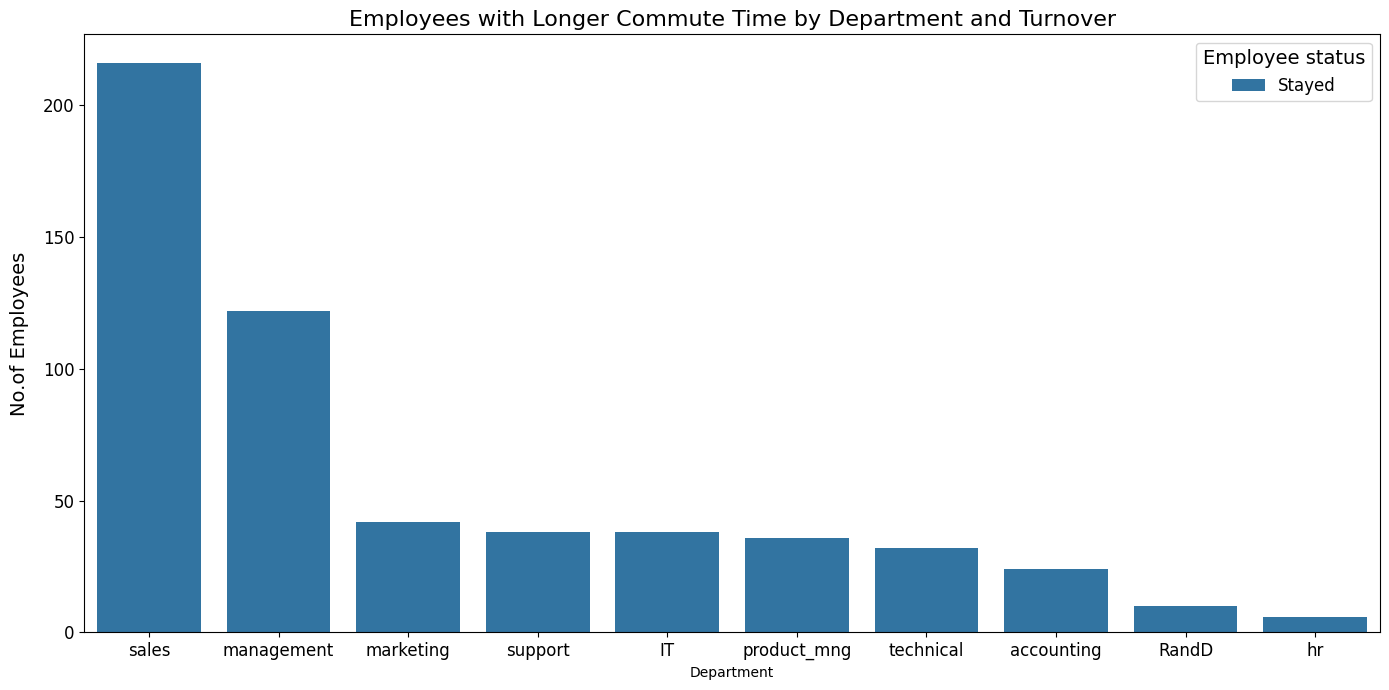

In [49]:
# visualize employees with longer commute times by department and employee status
plt.figure(figsize=[14,7])  # create a large figure for the departmental comparison
ax = sns.countplot(
    data=longer_commute,
    x='Department',
    hue='left',
    order=longer_commute['Department'].value_counts().index)  # compare stayed vs left employees with long commutes across departments

plt.title('Employees with Longer Commute Time by Department and Turnover', fontsize=16)  # add the chart title
plt.ylabel('No.of Employees', labelpad=10, fontsize=14)  # label the y-axis

ax.tick_params(axis='x', labelsize=12)  # format x-axis tick labels
ax.tick_params(axis='y', labelsize=12)  # format y-axis tick labels
plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend
plt.tight_layout()  # adjust spacing to prevent overlap

plt.show();  


- The top 3 departments are sales (leading as always), management and marketing. It could be these employees are receiving high salaries or their commitment to their jobs is commendable.
- Looking at the salaries, we can see that most of the employees are receiving medium salaries and coming next in line are employees with low salaries even higher than those with high salaries.
- The HR department may decide to carry out a survey with these employees to know why they choose to stay even with longer commute hours.

### 8. Do work accidents lead to employees leaving the company?

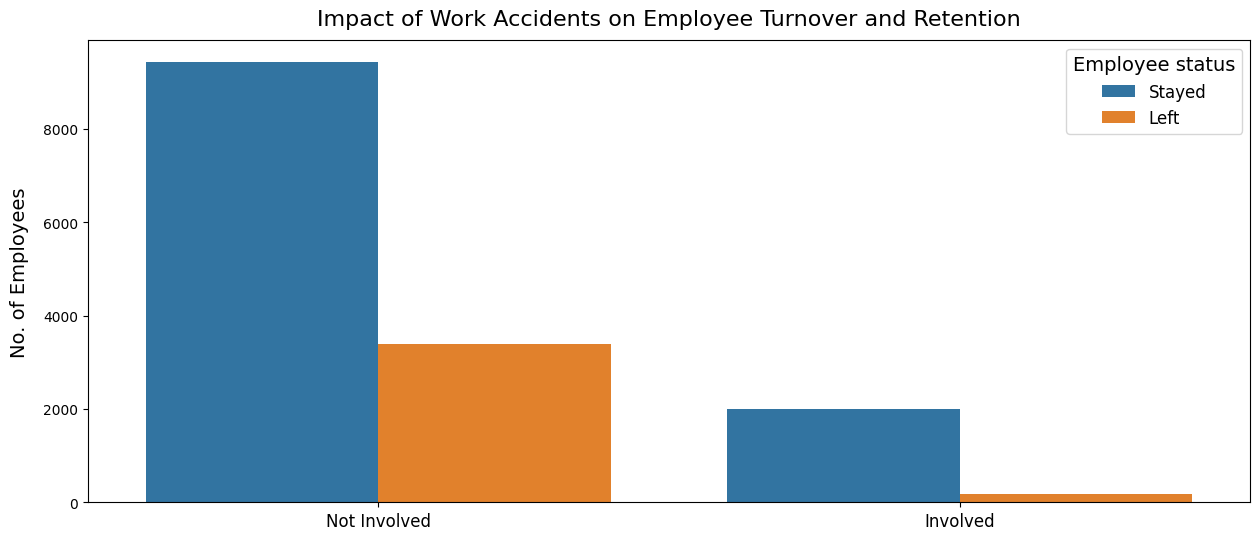

In [50]:
# plot work accident involvement against employee status
plt.figure(figsize=[15,6])  # create a wide figure for the accident comparison

sns.countplot(data=df, x='Work_accident', hue='left')  # compare stayed vs left employees by accident involvement

plt.xticks(ticks=[0,1], labels=['Not Involved', 'Involved'], fontsize=12)  # replace binary values with readable labels
plt.title('Impact of Work Accidents on Employee Turnover and Retention', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('', labelpad=10, fontsize=14)  # remove the x-axis label
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis

plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend

plt.show();  


The number of employees who left after being involved in a work accident is relatively small compared to those who were not involved in accidents. This suggest that work accidents is not a major contributing factor to employees leaving the company.

### 9. Are employees who are promoted more or less likely to stay with the company?

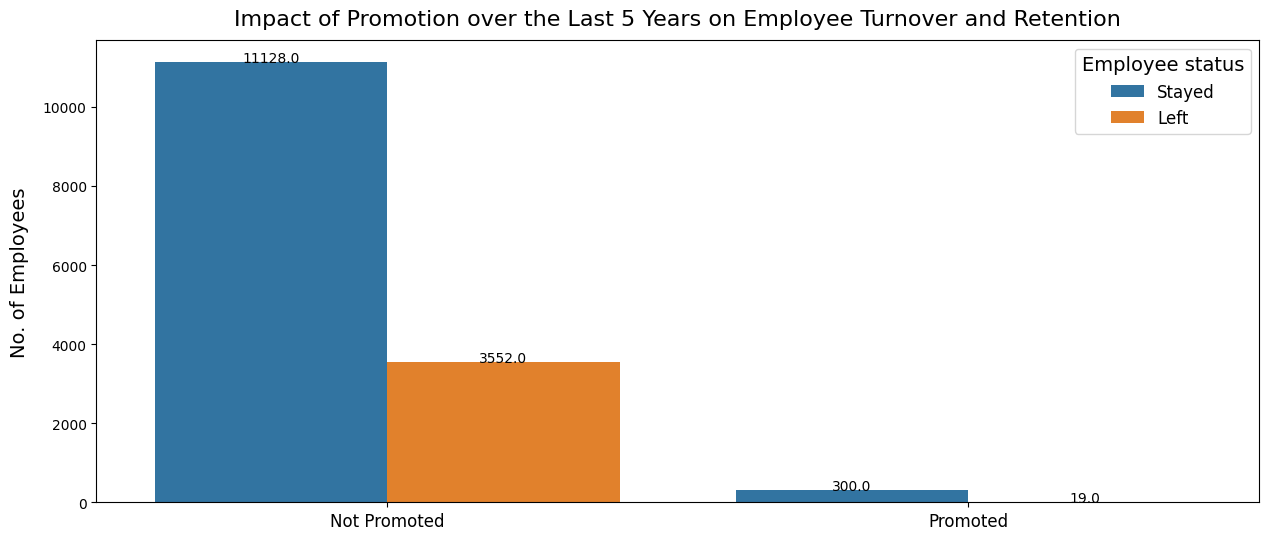

In [51]:
# plot promotion history against employee status
plt.figure(figsize=[15,6])  # create a wide figure for the promotion comparison

ax = sns.countplot(data=df, x='promotion_last_5years', hue='left')  # compare stayed vs left employees by promotion history

plt.xticks(ticks=[0,1], labels=['Not Promoted', 'Promoted'], fontsize=12)  # replace binary values with readable labels
plt.title('Impact of Promotion over the Last 5 Years on Employee Turnover and Retention', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('', labelpad=10, fontsize=14)  # remove the x-axis label
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis
plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend

# add data labels to the bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='baseline'
    )  # place the employee count above each bar

plt.show();  


Promotions over the past 5 years are infrequent, only 2% of the workforce have been promoted.

Majority of employees who received promotions in the last 5 years have remained with the company. The number of promoted employees who stayed is visibly higher than the number of those who left.

This suggests that promotions may contribute positively to employee retention, as those who were promoted are not leaving in large numbers like the employees who were not promoted.

### 10. How many employees who were trained in the past year decided to remain with the company?

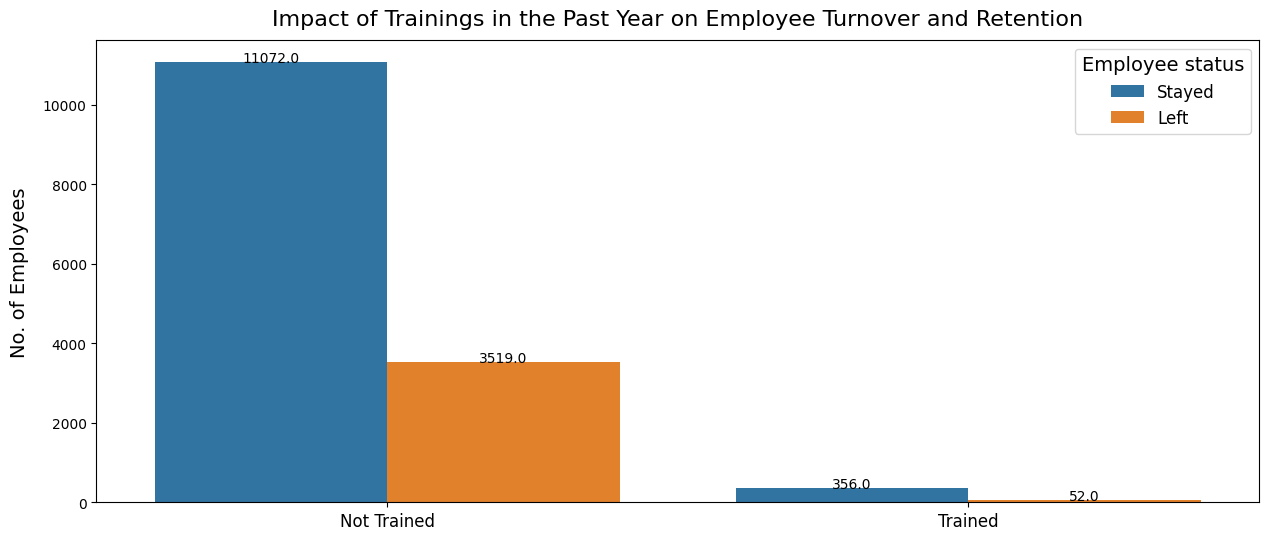

In [52]:
# plot training participation against employee status
plt.figure(figsize=[15,6])  # create a wide figure for the training comparison

ax = sns.countplot(data=df, x='Training_Last_Year', hue='left')  # compare stayed vs left employees by training participation

plt.xticks(ticks=[0,1], labels=['Not Trained', 'Trained'], fontsize=12)  # replace binary values with readable labels
plt.title('Impact of Trainings in the Past Year on Employee Turnover and Retention', fontsize=16, y=1.015)  # add the chart title
plt.xlabel('', labelpad=10, fontsize=14)  # remove the x-axis label
plt.ylabel('No. of Employees', labelpad=10, fontsize=14)  # label the y-axis
plt.legend(title='Employee status', labels=['Stayed', 'Left'], fontsize=12, title_fontsize=14)  # customize the legend

# add data labels to the bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',va='baseline')  # place the employee count above each bar

plt.show();  


More than 97% of employees did not receive trainings in the past year. Employees who received training in the past year have stayed with the company.

Trainings have been very infrequent in the company. A very large percentage of untrained employees have left the company.

####  Conclusion

Based on the comprehensive analysis of employee turnover and retention, the following conclusions can be drawn:
1. **Employee Satisfaction:** Overall employee satisfaction is moderate, but there is a concerning number of highly dissatisfied employees. This suggests that there are systemic issues within the company that need to be addressed.
2. **Performance Evaluations:** Both low and high performing employees are leaving, indicating that performance is not the sole factor in retention. Other factors, such as commute times, salary levels, and career development opportunities, play a significant role.
3. **Commute Times:** Longer commutes correlate with higher turnover, but there are exceptions for those with extremely long commutes, indicating other factors at play in retention.
4. **Salary Levels:** Higher salaries are associated with better retention, while lower salaries increase the likelihood of tumover.
5. **Promotions and Training:** Infrequent promotions and training opportunites contributes to turnover. Employees who receive promotions or training tend to stay, suggesting these are valued aspects of career development.
6. **Lack of career growth:** Employees who see few opportunities for advancement are more likely to leave.
7. **Departmental Turnover:** Sales, technical, and support departments experience the highest turnover, particularly among dissatisfied employees, which may highlight specific areas for improvement.
8. **Work Accidents:** Work accidents do not seem to be a significant factor in employee turnover. However, quite a number of employees have been involved in work accidents.
9. **Workload:** Both underutilization and overutilization contribute to turnover. Employees who have a balanced workload and work-life balance are more likely to stay with the company. Quiet a number of employees work more than 200 hours montly. Employees who are overworked or overcommitted are more likely to leave.

#### Recommendations

1. **Address Satisfaction Issues:** Implement regular assessments to identify and address the root causes of dissatisfaction such as high workloads, lack of career growth, and lack of training, particularly in the departments with the highest turnover.
2. **Review Workload Management:** Ensure employees are neither overburdened nor underutilized. Ensure that employees are not working on more than 3-4 projects per time to maintain engagement without causing burnout.
3. **Enhance Career Development Opportunities:** Increase the frequency of promotions and training to signal a clear pathway for career growth, which is likely to improve retention. Employees should be able to see a path for advancement within the company
4. **Adjust Salary Structures:** Review and adjust salaries, especially for those at the lower end, to improve satisfaction and reduce turnover.
5. **Flexible Work Arrangements:** Consider flexible working arrangements or remote/hybrid work options to alleviate the strain of long commutes.
6. **Focus on High Performers:** Develop retention strategies specifically for high performers who show a surprising tendency to leave.
7. **Department-Specific Strategies:** Sales, technical, and support departments require targeted strategies to improve employee satisfaction and reduce turnover as they have the highest number of leaving employees.
8. **Comprehensive Engagement Plan:** Develop a comprehensive employee engagement plan that addresses various aspects like work-life balance, recognition, and employee well-being.
9. **Recognize and reward employees:** Employees should feel that their hard work and contributions are appreciated. This can be done by providing regular feedback, offering recognition and rewards, and creating a culture of appreciation.

By addressing these key areas, the company can aim to reduce turnover rates, enhance employee satisfaction, and foster a work environment that supports employee retention and growth.
